# Adaptive Congestion-Aware Routing in Software-Defined Networks Using Reinforcement Learning 

Author: Aryan Karamtoth <spaciouscoder78@disroot.org>

License: BSD-2-Clause

## Installing Dependencies

Installing necessary python packages (Use Python 3.13)

**Dependencies**:
- networkx
- matplotlib
- numpy
- torch

In [1]:
pip install networkx matplotlib numpy torch

  Using cached scapy-2.7.0-py3-none-any.whl.metadata (5.8 kB)
Using cached scapy-2.7.0-py3-none-any.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.


## Generating a base network graph with 12 nodes

In the first step, we need to generate a base network graph with 12 nodes that depicts congestion in the network.

Red stands for congested node, Green stands for non-congested node

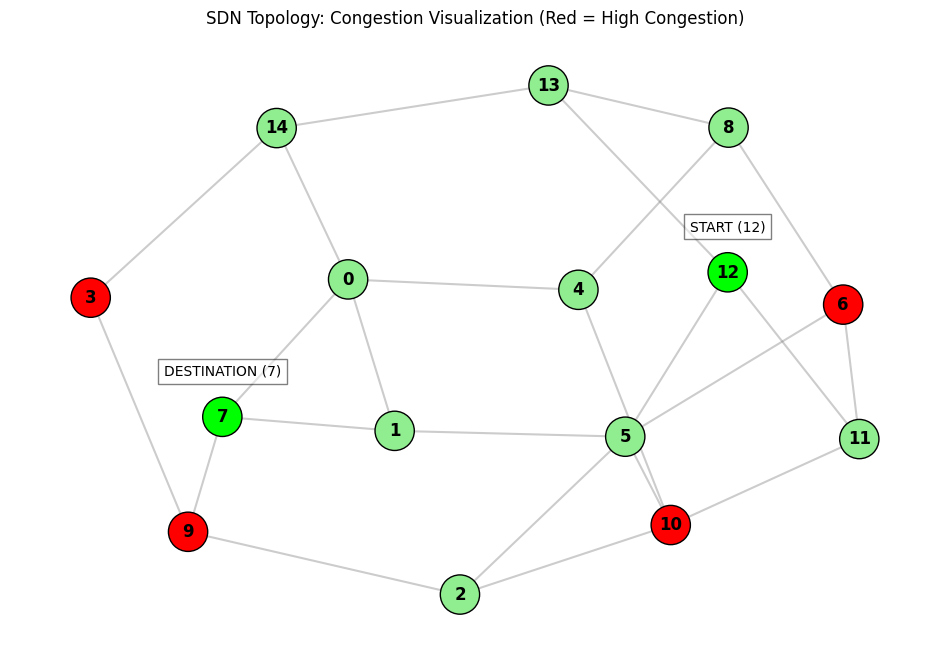

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# 1. Create the base graph (using your setup)
Graph = nx.waxman_graph(15, beta=0.4, alpha=0.1)
extra_edges = [
    (0,1), (0,4), (1,5), (2,5), (6,8), (7,9), (9,3), (8,4), (7,1), 
    (2,10), (10,11), (11,12), (12,13), (13,14), (14,0),           
    (5,12), (3,14), (6,11), (8,13), (4,10),                       
    (0,7), (2,9), (5,6)                                           
]
Graph.add_edges_from(extra_edges)

# 2. Define Start and Destination
start_node = 12
end_node = 7

# 3. Simulate Congestion Logic
# We create a dictionary where each node is assigned 'red' (congested) or 'green' (clear)
# We ensure the start and end nodes are always green so the path is possible
node_colors = []
for node in Graph.nodes():
    if node == start_node or node == end_node:
        node_colors.append('lime') # Start/End are always clear
    else:
        # 30% chance of a node being congested
        status = 'red' if random.random() < 0.3 else 'lightgreen'
        node_colors.append(status)

# 4. Visualization
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(Graph, seed=42) 

# Draw edges
nx.draw_networkx_edges(Graph, pos, width=1.5, alpha=0.4, edge_color='gray')

# Draw nodes with the color list we generated
nx.draw_networkx_nodes(Graph, pos, node_size=800, node_color=node_colors, edgecolors='black')

# Label nodes
nx.draw_networkx_labels(Graph, pos, font_size=12, font_weight='bold')

# Special labels for Start and End
plt.text(pos[start_node][0], pos[start_node][1]+0.1, s="START (12)", bbox=dict(facecolor='white', alpha=0.5), horizontalalignment='center')
plt.text(pos[end_node][0], pos[end_node][1]+0.1, s="DESTINATION (7)", bbox=dict(facecolor='white', alpha=0.5), horizontalalignment='center')

plt.title("SDN Topology: Congestion Visualization (Red = High Congestion)")
plt.axis('off')
plt.show()

## Creating a Reinforcement Learning Agent

We use the built-in features in the libraries that we installed and create a RL agent based on Q-Learning and DQN.

### Reinforcement Learning Agent in a Low Congestion Network

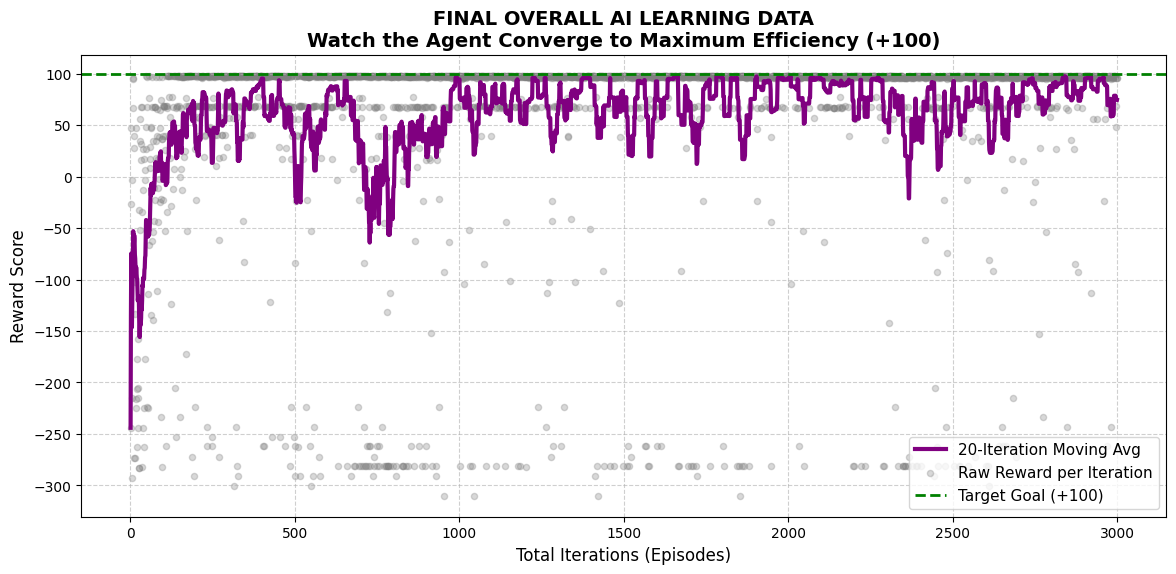


=== DYNAMIC ROUTING TEST RESULTS ===


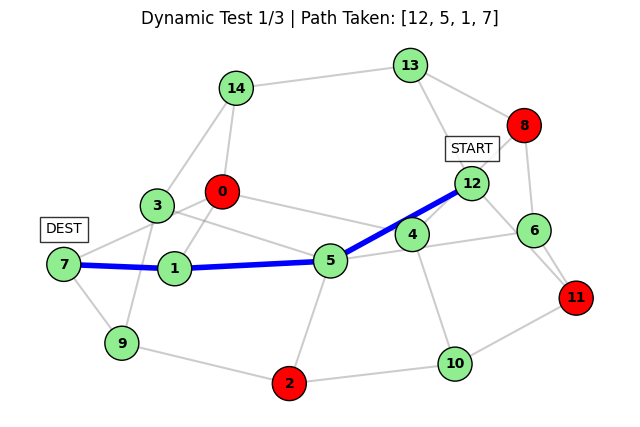

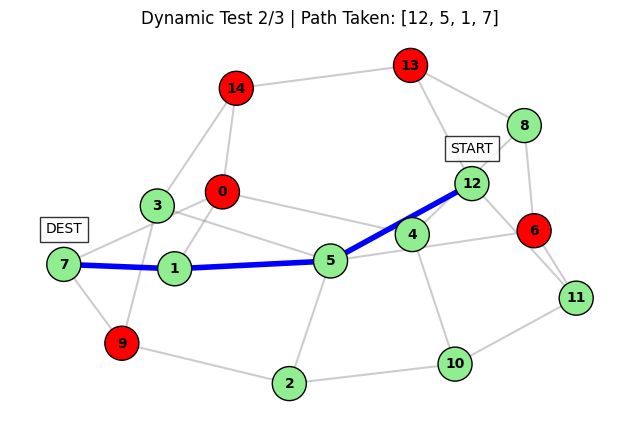

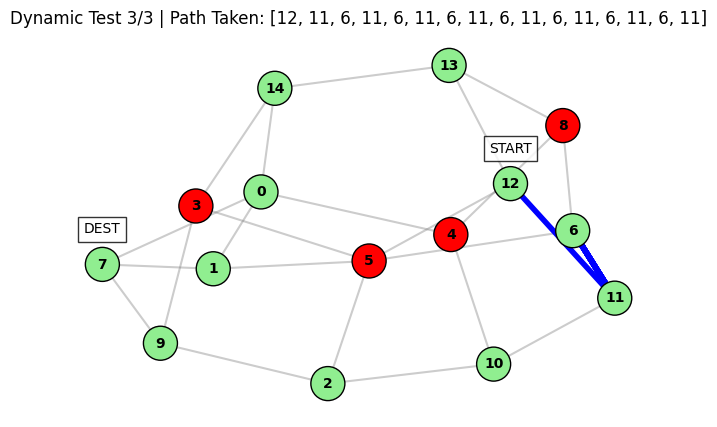

In [12]:
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from IPython.display import clear_output
import time

# ==========================================
# 1. SETUP FUNCTIONS (Graph & Model)
# ==========================================
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128) 
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

def create_graph():
    # 15-node base topology
    Graph = nx.waxman_graph(15, beta=0.4, alpha=0.1)
    extra_edges = [
        (0,1), (0,4), (1,5), (2,5), (6,8), (7,9), (9,3), (8,4), (7,1),
        (2,10), (10,11), (11,12), (12,13), (13,14), (14,0),
        (5,12), (3,14), (6,11), (8,13), (4,10),
        (0,7), (2,9), (5,6)
    ]
    Graph.add_edges_from(extra_edges)
    return Graph

def congestion_logic(Graph, start_node, end_node):
    # TRULY DYNAMIC LOGIC: Randomize until a valid path exists
    while True:
        node_colors = ['lightgreen'] * 15
        binary_state = np.zeros(15)
        
        for node in Graph.nodes():
            if node == start_node or node == end_node:
                continue 
            
            # 35% chance of congestion on any node
            if random.random() < 0.35: 
                node_colors[node] = 'red'
                binary_state[node] = 1
                
        # Check if map is logically solvable
        green_nodes = [n for n in Graph.nodes() if binary_state[n] == 0]
        subgraph = Graph.subgraph(green_nodes)
        if nx.has_path(subgraph, start_node, end_node):
            return node_colors, binary_state

def get_state_tensor(current_node, binary_congestion):
    pos_array = np.zeros(15)
    pos_array[current_node] = 1.0
    state = np.concatenate((pos_array, binary_congestion))
    return torch.FloatTensor(state).unsqueeze(0)

# ==========================================
# 2. TRAINING LOOP WITH LIVE GRAPHING
# ==========================================
my_graph = create_graph()
pos = nx.spring_layout(my_graph, seed=42) # Static layout for visual stability

start_node = 12
end_node = 7

# Initialize PyTorch Agent
agent = DQN(30, 15)
optimizer = optim.Adam(agent.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

memory = deque(maxlen=2000) 
batch_size = 32

episodes = 3000 # 1000 iterations for training
gamma = 0.95 
epsilon = 1.0 
epsilon_decay = 0.99 

# Data tracking for our graphs
rewards_history = []
moving_avg_rewards = [] 

print("Training Deep Q-Network... Please wait.")
time.sleep(1)

for i in range(episodes):
    my_colors, congestion_state = congestion_logic(my_graph, start_node, end_node)
    
    current_node = start_node
    path_taken = [current_node]
    episode_reward = 0

    for step in range(15): 
        state_tensor = get_state_tensor(current_node, congestion_state)
        
        # Action Selection (Explore vs Exploit)
        if random.random() < epsilon:
            next_node = random.choice(list(my_graph.neighbors(current_node)))
        else:
            q_values = agent(state_tensor)
            q_vals_numpy = q_values.detach().numpy()[0]
            valid_q_vals = {n: q_vals_numpy[n] for n in my_graph.neighbors(current_node)}
            next_node = max(valid_q_vals, key=valid_q_vals.get)

        # Environment Feedback (Reward)
        if next_node == end_node:
            reward = 100
            done = True
        elif next_node in path_taken:
            reward = -20 # Loop penalty
            done = False
        elif congestion_state[next_node] == 1:
            reward = -30 # Congestion penalty
            done = False
        else:
            reward = -1  # Step penalty
            done = False
            
        next_state_tensor = get_state_tensor(next_node, congestion_state)
        
        # Save to Replay Memory
        memory.append((state_tensor, next_node, reward, next_state_tensor, done))
        
        # Train PyTorch model
        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)
            optimizer.zero_grad()
            loss = 0
            for s, a, r, n_s, d in batch:
                q_val = agent(s)[0][a] 
                max_next_q = agent(n_s).max() 
                target = r + gamma * max_next_q * (1 - int(d))
                loss += loss_fn(q_val, target.detach()) 
            
            loss = loss / batch_size
            loss.backward()
            optimizer.step()
        
        path_taken.append(next_node)
        current_node = next_node
        episode_reward += reward
        
        if done:
            break
            
    # Track the data over each iteration
    rewards_history.append(episode_reward)
    moving_avg_rewards.append(np.mean(rewards_history[-20:])) 
    epsilon = max(0.01, epsilon * epsilon_decay)

    # ---------------------------------------------------------
    # DASHBOARD: UPDATE GRAPH EVERY 50 ITERATIONS
    # ---------------------------------------------------------
    if (i + 1) % 50 == 0:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # --- LEFT: Physical Network ---
        nx.draw_networkx_edges(my_graph, pos, ax=ax1, width=1.5, alpha=0.4, edge_color='gray')
        nx.draw_networkx_nodes(my_graph, pos, ax=ax1, node_size=600, node_color=my_colors, edgecolors='black')
        nx.draw_networkx_labels(my_graph, pos, ax=ax1, font_size=10, font_weight='bold')
        
        path_edges = list(zip(path_taken, path_taken[1:]))
        nx.draw_networkx_edges(my_graph, pos, ax=ax1, edgelist=path_edges, width=4, edge_color='blue')
        
        ax1.text(pos[start_node][0], pos[start_node][1]+0.15, s="START", bbox=dict(facecolor='white', alpha=0.7), ha='center')
        ax1.text(pos[end_node][0], pos[end_node][1]+0.15, s="DEST", bbox=dict(facecolor='white', alpha=0.7), ha='center')
        ax1.set_title(f"Episode {i+1}/{episodes} | Epsilon: {epsilon:.2f}\nCurrent Path: {path_taken}")
        ax1.axis('off')

        # --- RIGHT: Data Graph Over Each Iteration ---
        ax2.plot(range(1, len(moving_avg_rewards) + 1), moving_avg_rewards, color='purple', linewidth=2.5, label='20-Iteration Moving Avg')
        ax2.scatter(range(1, len(rewards_history) + 1), rewards_history, color='gray', alpha=0.25, s=15, label='Raw Reward per Iteration')
        ax2.set_title("AI Learning Data (Reward vs. Iteration)")
        ax2.set_xlabel("Iteration (Episode)")
        ax2.set_ylabel("Total Reward")
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.axhline(y=100, color='green', linestyle='--', label='Target Goal (+100)')
        ax2.legend(loc="lower right")
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 3. FINAL LEARNING CURVE GRAPH
# ==========================================
print("\nTraining Complete! Plotting Final Learning Data...")
time.sleep(1)
clear_output(wait=True)

plt.figure(figsize=(14, 6))
plt.plot(range(1, len(moving_avg_rewards) + 1), moving_avg_rewards, color='purple', linewidth=3, label='20-Iteration Moving Avg')
plt.scatter(range(1, len(rewards_history) + 1), rewards_history, color='gray', alpha=0.3, s=20, label='Raw Reward per Iteration')
plt.title("FINAL OVERALL AI LEARNING DATA\nWatch the Agent Converge to Maximum Efficiency (+100)", fontsize=14, fontweight='bold')
plt.xlabel("Total Iterations (Episodes)", fontsize=12)
plt.ylabel("Reward Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Target Goal (+100)')
plt.legend(loc="lower right", fontsize=11)
plt.show()



# ==========================================
# 4. DYNAMIC TESTING PHASE
# ==========================================
print("\n=== DYNAMIC ROUTING TEST RESULTS ===")

for test_run in range(3):
    my_colors, congestion_state = congestion_logic(my_graph, start_node, end_node)
    current_node = start_node
    path_taken = [current_node]
    
    # Run fully trained agent (Epsilon = 0)
    for step in range(15):
        state_tensor = get_state_tensor(current_node, congestion_state)
        q_values = agent(state_tensor)
        q_vals_numpy = q_values.detach().numpy()[0]
        valid_q_vals = {n: q_vals_numpy[n] for n in my_graph.neighbors(current_node)}
        next_node = max(valid_q_vals, key=valid_q_vals.get)
        
        path_taken.append(next_node)
        if next_node == end_node:
            break
        current_node = next_node

    # Draw test maps sequentially (Stacked)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    nx.draw_networkx_edges(my_graph, pos, ax=ax1, width=1.5, alpha=0.4, edge_color='gray')
    nx.draw_networkx_nodes(my_graph, pos, ax=ax1, node_size=600, node_color=my_colors, edgecolors='black')
    nx.draw_networkx_labels(my_graph, pos, ax=ax1, font_size=10, font_weight='bold')
    
    path_edges = list(zip(path_taken, path_taken[1:]))
    nx.draw_networkx_edges(my_graph, pos, ax=ax1, edgelist=path_edges, width=4, edge_color='blue')
    
    ax1.text(pos[start_node][0], pos[start_node][1]+0.15, s="START", bbox=dict(facecolor='white', alpha=0.8), ha='center')
    ax1.text(pos[end_node][0], pos[end_node][1]+0.15, s="DEST", bbox=dict(facecolor='white', alpha=0.8), ha='center')
    ax1.set_title(f"Dynamic Test {test_run+1}/3 | Path Taken: {path_taken}", fontsize=12)
    ax1.axis('off')
    
    plt.show()

### Reinforcement Learning Agent in a High Congestion Network

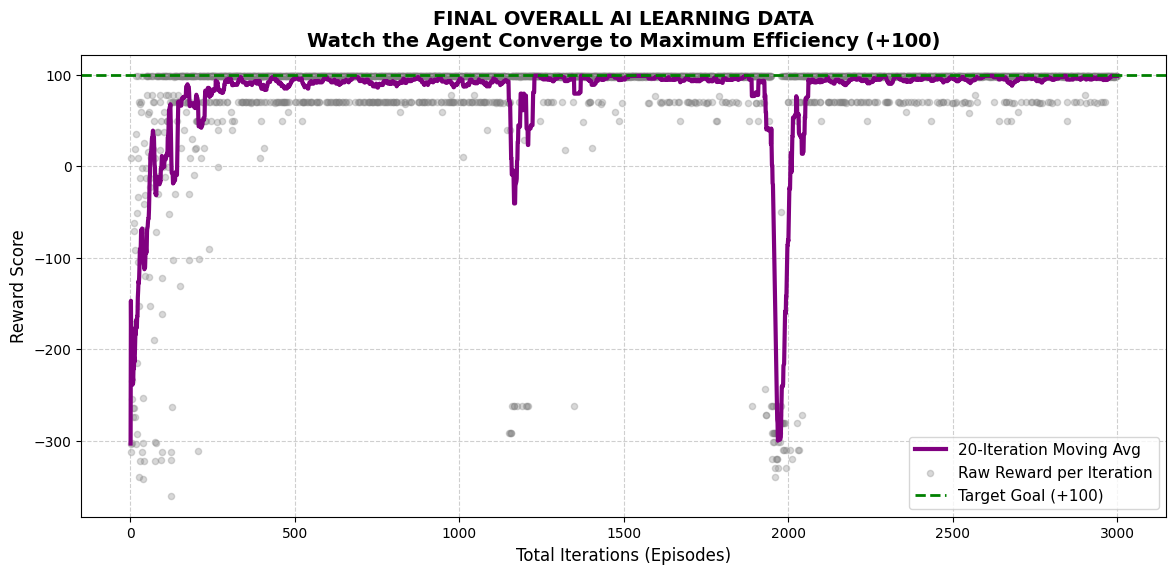


=== DYNAMIC ROUTING TEST RESULTS ===


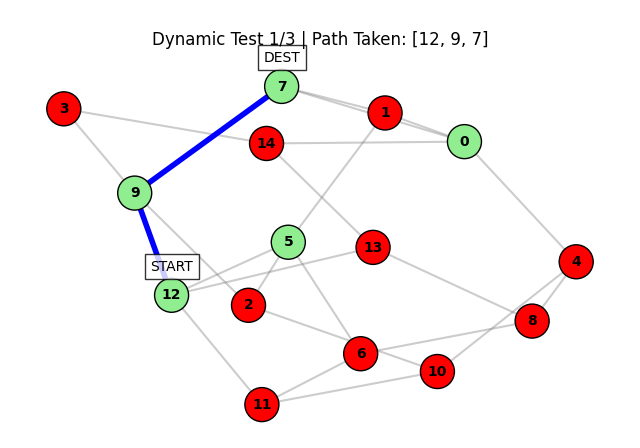

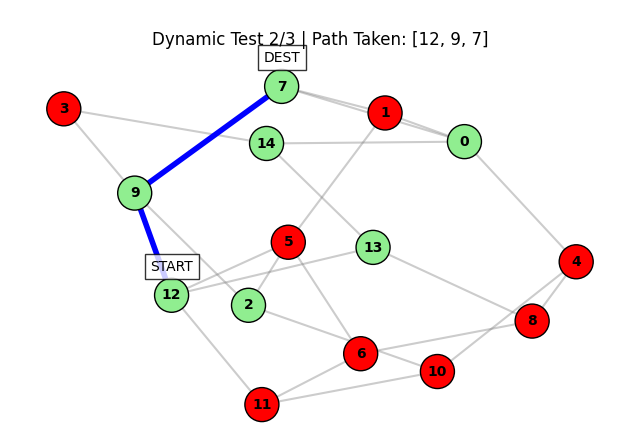

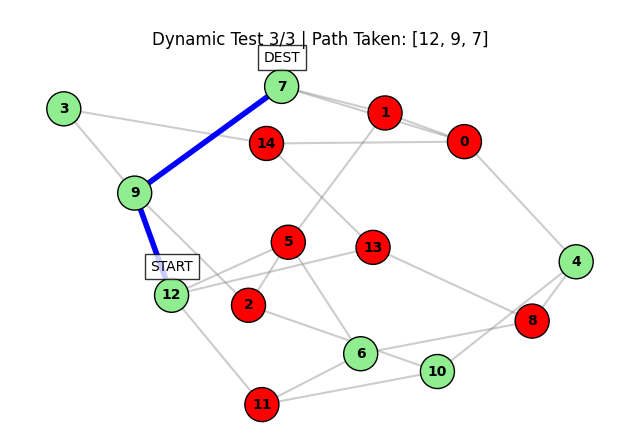

In [23]:
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from IPython.display import clear_output
import time

# ==========================================
# 1. SETUP FUNCTIONS (Graph & Model)
# ==========================================
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128) 
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

def create_graph():
    # 15-node base topology
    Graph = nx.waxman_graph(15, beta=0.4, alpha=0.1)
    extra_edges = [
        (0,1), (0,4), (1,5), (2,5), (6,8), (7,9), (9,3), (8,4), (7,1),
        (2,10), (10,11), (11,12), (12,13), (13,14), (14,0),
        (5,12), (3,14), (6,11), (8,13), (4,10),
        (0,7), (2,9), (5,6)
    ]
    Graph.add_edges_from(extra_edges)
    return Graph

def congestion_logic(Graph, start_node, end_node):
    # TRULY DYNAMIC LOGIC: Randomize until a valid path exists
    while True:
        node_colors = ['lightgreen'] * 15
        binary_state = np.zeros(15)
        
        for node in Graph.nodes():
            if node == start_node or node == end_node:
                continue 
            
            # 35% chance of congestion on any node
            if random.random() < 0.70: 
                node_colors[node] = 'red'
                binary_state[node] = 1
                
        # Check if map is logically solvable
        green_nodes = [n for n in Graph.nodes() if binary_state[n] == 0]
        subgraph = Graph.subgraph(green_nodes)
        if nx.has_path(subgraph, start_node, end_node):
            return node_colors, binary_state

def get_state_tensor(current_node, binary_congestion):
    pos_array = np.zeros(15)
    pos_array[current_node] = 1.0
    state = np.concatenate((pos_array, binary_congestion))
    return torch.FloatTensor(state).unsqueeze(0)

# ==========================================
# 2. TRAINING LOOP WITH LIVE GRAPHING
# ==========================================
my_graph = create_graph()
pos = nx.spring_layout(my_graph, seed=42) # Static layout for visual stability

start_node = 12
end_node = 7

# Initialize PyTorch Agent
agent = DQN(30, 15)
optimizer = optim.Adam(agent.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

memory = deque(maxlen=2000) 
batch_size = 32

episodes = 3000 # 1000 iterations for training
gamma = 0.95 
epsilon = 1.0 
epsilon_decay = 0.99 

# Data tracking for our graphs
rewards_history = []
moving_avg_rewards = [] 

print("Training Deep Q-Network... Please wait.")
time.sleep(1)

for i in range(episodes):
    my_colors, congestion_state = congestion_logic(my_graph, start_node, end_node)
    
    current_node = start_node
    path_taken = [current_node]
    episode_reward = 0

    for step in range(15): 
        state_tensor = get_state_tensor(current_node, congestion_state)
        
        # Action Selection (Explore vs Exploit)
        if random.random() < epsilon:
            next_node = random.choice(list(my_graph.neighbors(current_node)))
        else:
            q_values = agent(state_tensor)
            q_vals_numpy = q_values.detach().numpy()[0]
            valid_q_vals = {n: q_vals_numpy[n] for n in my_graph.neighbors(current_node)}
            next_node = max(valid_q_vals, key=valid_q_vals.get)

        # Environment Feedback (Reward)
        if next_node == end_node:
            reward = 100
            done = True
        elif next_node in path_taken:
            reward = -20 # Loop penalty
            done = False
        elif congestion_state[next_node] == 1:
            reward = -30 # Congestion penalty
            done = False
        else:
            reward = -1  # Step penalty
            done = False
            
        next_state_tensor = get_state_tensor(next_node, congestion_state)
        
        # Save to Replay Memory
        memory.append((state_tensor, next_node, reward, next_state_tensor, done))
        
        # Train PyTorch model
        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)
            optimizer.zero_grad()
            loss = 0
            for s, a, r, n_s, d in batch:
                q_val = agent(s)[0][a] 
                max_next_q = agent(n_s).max() 
                target = r + gamma * max_next_q * (1 - int(d))
                loss += loss_fn(q_val, target.detach()) 
            
            loss = loss / batch_size
            loss.backward()
            optimizer.step()
        
        path_taken.append(next_node)
        current_node = next_node
        episode_reward += reward
        
        if done:
            break
            
    # Track the data over each iteration
    rewards_history.append(episode_reward)
    moving_avg_rewards.append(np.mean(rewards_history[-20:])) 
    epsilon = max(0.01, epsilon * epsilon_decay)

    # ---------------------------------------------------------
    # DASHBOARD: UPDATE GRAPH EVERY 50 ITERATIONS
    # ---------------------------------------------------------
    if (i + 1) % 50 == 0:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # --- LEFT: Physical Network ---
        nx.draw_networkx_edges(my_graph, pos, ax=ax1, width=1.5, alpha=0.4, edge_color='gray')
        nx.draw_networkx_nodes(my_graph, pos, ax=ax1, node_size=600, node_color=my_colors, edgecolors='black')
        nx.draw_networkx_labels(my_graph, pos, ax=ax1, font_size=10, font_weight='bold')
        
        path_edges = list(zip(path_taken, path_taken[1:]))
        nx.draw_networkx_edges(my_graph, pos, ax=ax1, edgelist=path_edges, width=4, edge_color='blue')
        
        ax1.text(pos[start_node][0], pos[start_node][1]+0.15, s="START", bbox=dict(facecolor='white', alpha=0.7), ha='center')
        ax1.text(pos[end_node][0], pos[end_node][1]+0.15, s="DEST", bbox=dict(facecolor='white', alpha=0.7), ha='center')
        ax1.set_title(f"Episode {i+1}/{episodes} | Epsilon: {epsilon:.2f}\nCurrent Path: {path_taken}")
        ax1.axis('off')

        # --- RIGHT: Data Graph Over Each Iteration ---
        ax2.plot(range(1, len(moving_avg_rewards) + 1), moving_avg_rewards, color='purple', linewidth=2.5, label='20-Iteration Moving Avg')
        ax2.scatter(range(1, len(rewards_history) + 1), rewards_history, color='gray', alpha=0.25, s=15, label='Raw Reward per Iteration')
        ax2.set_title("AI Learning Data (Reward vs. Iteration)")
        ax2.set_xlabel("Iteration (Episode)")
        ax2.set_ylabel("Total Reward")
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.axhline(y=100, color='green', linestyle='--', label='Target Goal (+100)')
        ax2.legend(loc="lower right")
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 3. FINAL LEARNING CURVE GRAPH
# ==========================================
print("\nTraining Complete! Plotting Final Learning Data...")
time.sleep(1)
clear_output(wait=True)

plt.figure(figsize=(14, 6))
plt.plot(range(1, len(moving_avg_rewards) + 1), moving_avg_rewards, color='purple', linewidth=3, label='20-Iteration Moving Avg')
plt.scatter(range(1, len(rewards_history) + 1), rewards_history, color='gray', alpha=0.3, s=20, label='Raw Reward per Iteration')
plt.title("FINAL OVERALL AI LEARNING DATA\nWatch the Agent Converge to Maximum Efficiency (+100)", fontsize=14, fontweight='bold')
plt.xlabel("Total Iterations (Episodes)", fontsize=12)
plt.ylabel("Reward Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Target Goal (+100)')
plt.legend(loc="lower right", fontsize=11)
plt.show()



# ==========================================
# 4. DYNAMIC TESTING PHASE
# ==========================================
print("\n=== DYNAMIC ROUTING TEST RESULTS ===")

for test_run in range(3):
    my_colors, congestion_state = congestion_logic(my_graph, start_node, end_node)
    current_node = start_node
    path_taken = [current_node]
    
    # Run fully trained agent (Epsilon = 0)
    for step in range(15):
        state_tensor = get_state_tensor(current_node, congestion_state)
        q_values = agent(state_tensor)
        q_vals_numpy = q_values.detach().numpy()[0]
        valid_q_vals = {n: q_vals_numpy[n] for n in my_graph.neighbors(current_node)}
        next_node = max(valid_q_vals, key=valid_q_vals.get)
        
        path_taken.append(next_node)
        if next_node == end_node:
            break
        current_node = next_node

    # Draw test maps sequentially (Stacked)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    nx.draw_networkx_edges(my_graph, pos, ax=ax1, width=1.5, alpha=0.4, edge_color='gray')
    nx.draw_networkx_nodes(my_graph, pos, ax=ax1, node_size=600, node_color=my_colors, edgecolors='black')
    nx.draw_networkx_labels(my_graph, pos, ax=ax1, font_size=10, font_weight='bold')
    
    path_edges = list(zip(path_taken, path_taken[1:]))
    nx.draw_networkx_edges(my_graph, pos, ax=ax1, edgelist=path_edges, width=4, edge_color='blue')
    
    ax1.text(pos[start_node][0], pos[start_node][1]+0.15, s="START", bbox=dict(facecolor='white', alpha=0.8), ha='center')
    ax1.text(pos[end_node][0], pos[end_node][1]+0.15, s="DEST", bbox=dict(facecolor='white', alpha=0.8), ha='center')
    ax1.set_title(f"\nDynamic Test {test_run+1}/3 | Path Taken: {path_taken}", fontsize=12)
    ax1.axis('off')
    
    plt.show()

## Plot of Average Low Congestion

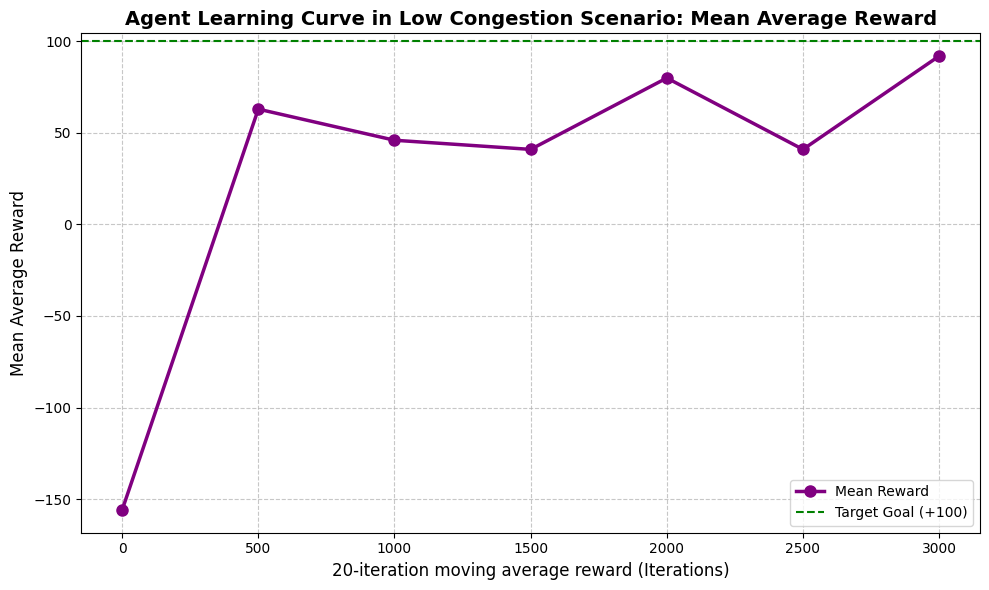

In [26]:
import matplotlib.pyplot as plt

# Data points provided
x = [0, 500, 1000, 1500, 2000, 2500, 3000]
y = [-156, 63, 46, 41, 80, 41, 92]

plt.figure(figsize=(10, 6))

# Plotting the line and markers
plt.plot(x, y, marker='o', linestyle='-', color='purple', linewidth=2.5, markersize=8, label='Mean Reward')

# Formatting the graph
plt.title("Agent Learning Curve in Low Congestion Scenario: Mean Average Reward", fontsize=14, fontweight='bold')
plt.xlabel("20-iteration moving average reward (Iterations)", fontsize=12)
plt.ylabel("Mean Average Reward", fontsize=12)

# Adding gridlines and target goal line
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=100, color='green', linestyle='--', label='Target Goal (+100)')
plt.legend(loc="lower right")

# Rendering and saving
plt.tight_layout()
plt.show()

## Plot of Average High Congestion

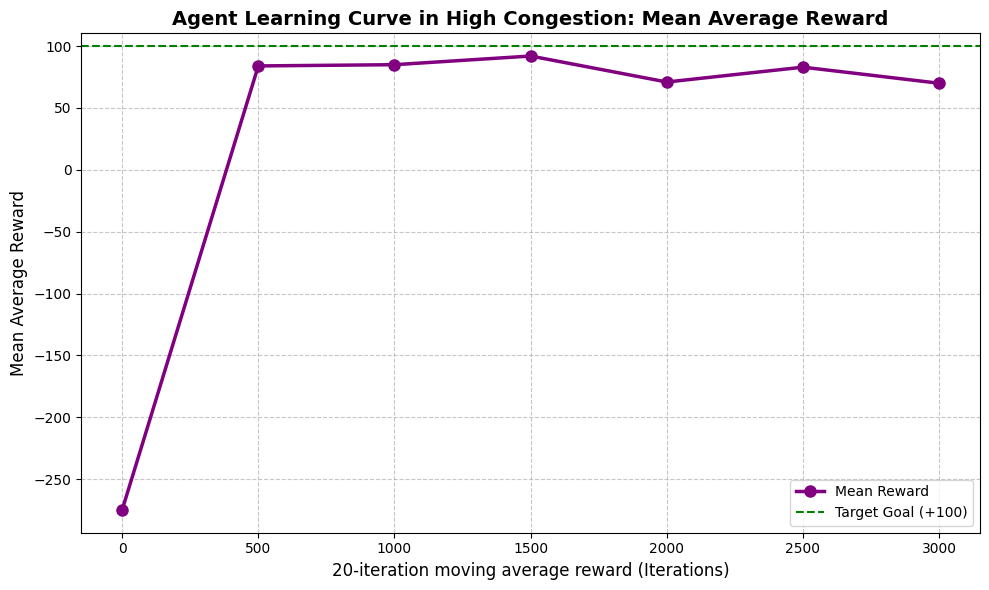

In [27]:
import matplotlib.pyplot as plt

# Data points provided
x = [0, 500, 1000, 1500, 2000, 2500, 3000]
y = [-275, 84, 85, 92, 71, 83, 70]

plt.figure(figsize=(10, 6))

# Plotting the line and markers
plt.plot(x, y, marker='o', linestyle='-', color='purple', linewidth=2.5, markersize=8, label='Mean Reward')

# Formatting the graph
plt.title("Agent Learning Curve in High Congestion: Mean Average Reward", fontsize=14, fontweight='bold')
plt.xlabel("20-iteration moving average reward (Iterations)", fontsize=12)
plt.ylabel("Mean Average Reward", fontsize=12)

# Adding gridlines and target goal line
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=100, color='green', linestyle='--', label='Target Goal (+100)')
plt.legend(loc="lower right")

# Rendering and saving
plt.tight_layout()
plt.show()

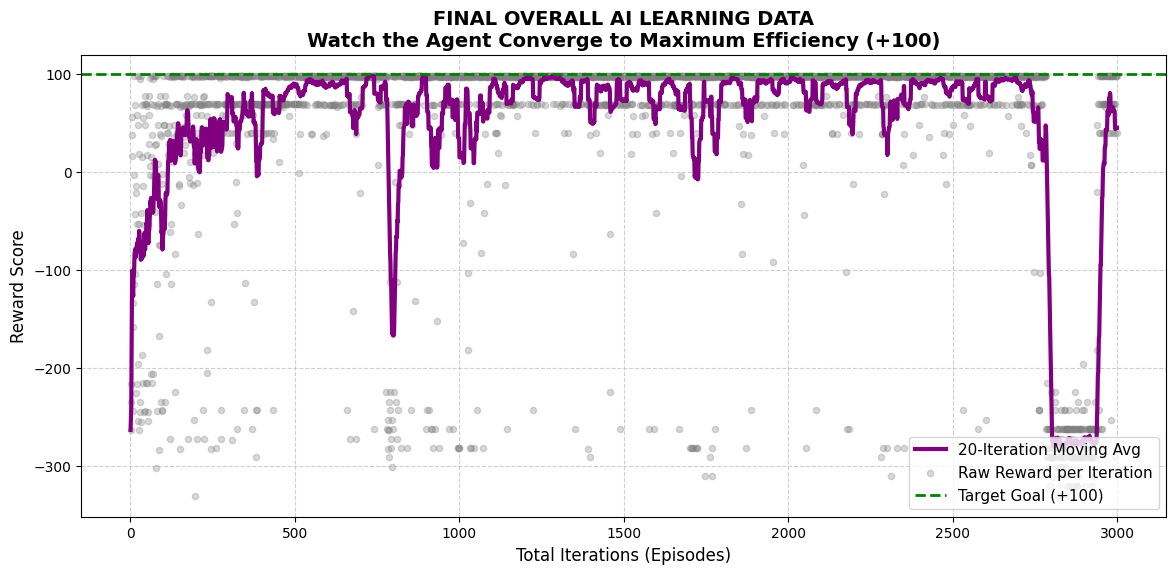


=== DYNAMIC ROUTING TEST RESULTS ===


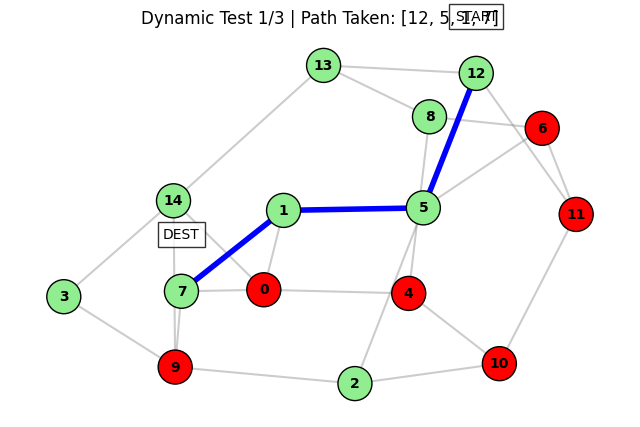

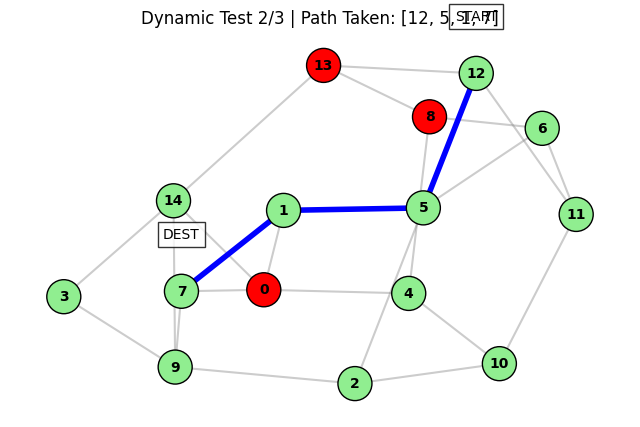

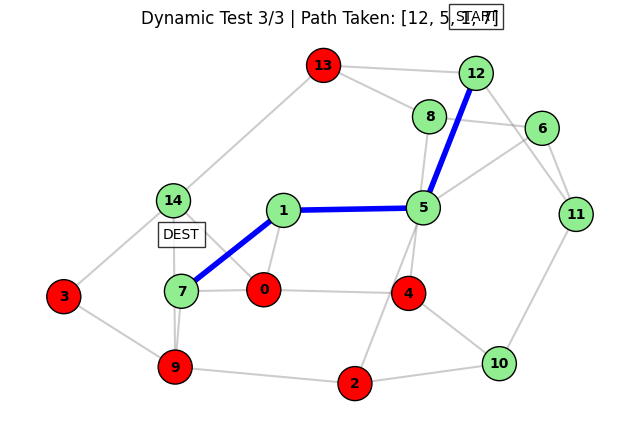

In [2]:
 
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from IPython.display import clear_output
import time

# ==========================================
# FIX #1: Seeds for reproducibility
# (non-breaking: doesn't affect methodology)
# ==========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ==========================================
# 1. SETUP FUNCTIONS (Graph & Model)
# ==========================================
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


def create_graph():
    # Waxman graph as described in the paper (Section III.A)
    # alpha=0.1, beta=0.4, 15 nodes
    Graph = nx.waxman_graph(15, beta=0.4, alpha=0.1)
    extra_edges = [
        (0, 1), (0, 4), (1, 5), (2, 5), (6, 8), (7, 9), (9, 3), (8, 4), (7, 1),
        (2, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 0),
        (5, 12), (3, 14), (6, 11), (8, 13), (4, 10),
        (0, 7), (2, 9), (5, 6)
    ]
    Graph.add_edges_from(extra_edges)
    return Graph


def congestion_logic(Graph, start_node, end_node):
    # 35% congestion probability as described in paper (Section III.A)
    # Change to 0.70 for high-congestion scenario
    while True:
        node_colors = ['lightgreen'] * 15
        binary_state = np.zeros(15)

        for node in Graph.nodes():
            if node == start_node or node == end_node:
                continue
            if random.random() < 0.35:
                node_colors[node] = 'red'
                binary_state[node] = 1

        # Solvability constraint using nx.has_path() as described in paper
        green_nodes = [n for n in Graph.nodes() if binary_state[n] == 0]
        subgraph = Graph.subgraph(green_nodes)
        if nx.has_path(subgraph, start_node, end_node):
            return node_colors, binary_state


def get_state_tensor(current_node, binary_congestion):
    # 30-dim state: one-hot position (15) + binary congestion (15)
    # as described in paper Section III.B.1
    pos_array = np.zeros(15)
    pos_array[current_node] = 1.0
    state = np.concatenate((pos_array, binary_congestion))
    return torch.FloatTensor(state).unsqueeze(0)


# ==========================================
# 2. TRAINING SETUP
# ==========================================
my_graph = create_graph()
pos = nx.spring_layout(my_graph, seed=42)

start_node = 12
end_node = 7

# Single DQN as described in paper (Section III.C)
agent = DQN(30, 15)
optimizer = optim.Adam(agent.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

memory = deque(maxlen=2000)
batch_size = 32

episodes = 3000
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.99  # As described in paper: ε_k+1 = ε_k × 0.99

rewards_history = []
moving_avg_rewards = []

print("Training Deep Q-Network... Please wait.")
time.sleep(1)

# ==========================================
# 3. TRAINING LOOP
# (matches paper Fig. 1 flow: optimize per step)
# ==========================================
for i in range(episodes):
    my_colors, congestion_state = congestion_logic(my_graph, start_node, end_node)

    current_node = start_node
    path_taken = [current_node]
    episode_reward = 0

    for step in range(15):  # T=15 horizon as described in paper Section III.A
        state_tensor = get_state_tensor(current_node, congestion_state)

        # ε-greedy exploration as described in paper Section III.C.4
        if random.random() < epsilon:
            next_node = random.choice(list(my_graph.neighbors(current_node)))
        else:
            # FIX #2: torch.no_grad() during inference (non-breaking correctness fix)
            with torch.no_grad():
                q_values = agent(state_tensor)
            q_vals_numpy = q_values.numpy()[0]
            valid_q_vals = {n: q_vals_numpy[n] for n in my_graph.neighbors(current_node)}
            next_node = max(valid_q_vals, key=valid_q_vals.get)

        # Reward function as described in paper Section III.B.3
        if next_node == end_node:
            reward = 100   # +100 goal reward, fixed anchor as per paper
            done = True
        elif next_node in path_taken:
            reward = -20   # Loop penalty
            done = False
        elif congestion_state[next_node] == 1:
            reward = -30   # Congestion penalty
            done = False
        else:
            reward = -1    # Step/latency penalty
            done = False

        next_state_tensor = get_state_tensor(next_node, congestion_state)
        memory.append((state_tensor, next_node, reward, next_state_tensor, done))

        # FIX #3: Vectorized batch loss using proper tensors (non-breaking bug fix)
        # Replaces the original `loss = 0` (int) accumulation loop
        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)

            states      = torch.cat([b[0] for b in batch])
            actions     = torch.tensor([b[1] for b in batch])
            rewards_b   = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            next_states = torch.cat([b[3] for b in batch])
            dones_b     = torch.tensor([b[4] for b in batch], dtype=torch.float32)

            # Q-values for actions taken
            q_vals = agent(states).gather(1, actions.unsqueeze(1)).squeeze(1)

            # Target using same network (as described in paper — no target net)
            with torch.no_grad():
                max_next_q = agent(next_states).max(dim=1).values

            targets = rewards_b + gamma * max_next_q * (1 - dones_b)

            loss = loss_fn(q_vals, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        path_taken.append(next_node)
        current_node = next_node
        episode_reward += reward

        if done:
            break

    rewards_history.append(episode_reward)
    moving_avg_rewards.append(np.mean(rewards_history[-20:]))
    # ε decay as per paper: ε_k+1 = ε_k × 0.99, floor at 0.01
    epsilon = max(0.01, epsilon * epsilon_decay)

    # Dashboard every 50 episodes
    if (i + 1) % 50 == 0:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        nx.draw_networkx_edges(my_graph, pos, ax=ax1, width=1.5, alpha=0.4, edge_color='gray')
        nx.draw_networkx_nodes(my_graph, pos, ax=ax1, node_size=600, node_color=my_colors, edgecolors='black')
        nx.draw_networkx_labels(my_graph, pos, ax=ax1, font_size=10, font_weight='bold')

        path_edges = list(zip(path_taken, path_taken[1:]))
        nx.draw_networkx_edges(my_graph, pos, ax=ax1, edgelist=path_edges, width=4, edge_color='blue')

        ax1.text(pos[start_node][0], pos[start_node][1] + 0.15, s="START",
                 bbox=dict(facecolor='white', alpha=0.7), ha='center')
        ax1.text(pos[end_node][0],   pos[end_node][1]   + 0.15, s="DEST",
                 bbox=dict(facecolor='white', alpha=0.7), ha='center')
        ax1.set_title(f"Episode {i+1}/{episodes} | Epsilon: {epsilon:.2f}\nCurrent Path: {path_taken}")
        ax1.axis('off')

        ax2.plot(range(1, len(moving_avg_rewards) + 1), moving_avg_rewards,
                 color='purple', linewidth=2.5, label='20-Iteration Moving Avg')
        ax2.scatter(range(1, len(rewards_history) + 1), rewards_history,
                    color='gray', alpha=0.25, s=15, label='Raw Reward per Iteration')
        ax2.set_title("AI Learning Data (Reward vs. Iteration)")
        ax2.set_xlabel("Iteration (Episode)")
        ax2.set_ylabel("Total Reward")
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.axhline(y=100, color='green', linestyle='--', label='Target Goal (+100)')
        ax2.legend(loc="lower right")

        plt.tight_layout()
        plt.show()

# ==========================================
# 4. FINAL LEARNING CURVE
# ==========================================
print("\nTraining Complete! Plotting Final Learning Data...")
time.sleep(1)
clear_output(wait=True)

plt.figure(figsize=(14, 6))
plt.plot(range(1, len(moving_avg_rewards) + 1), moving_avg_rewards,
         color='purple', linewidth=3, label='20-Iteration Moving Avg')
plt.scatter(range(1, len(rewards_history) + 1), rewards_history,
            color='gray', alpha=0.3, s=20, label='Raw Reward per Iteration')
plt.title("FINAL OVERALL AI LEARNING DATA\nWatch the Agent Converge to Maximum Efficiency (+100)",
          fontsize=14, fontweight='bold')
plt.xlabel("Total Iterations (Episodes)", fontsize=12)
plt.ylabel("Reward Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Target Goal (+100)')
plt.legend(loc="lower right", fontsize=11)
plt.show()

# ==========================================
# 5. DYNAMIC TESTING PHASE
# ε fixed at 0.0 as described in paper Section III.C.4
# ==========================================
print("\n=== DYNAMIC ROUTING TEST RESULTS ===")

for test_run in range(3):
    my_colors, congestion_state = congestion_logic(my_graph, start_node, end_node)
    current_node = start_node
    path_taken = [current_node]

    for step in range(15):
        state_tensor = get_state_tensor(current_node, congestion_state)
        with torch.no_grad():
            q_values = agent(state_tensor)
        q_vals_numpy = q_values.numpy()[0]
        valid_q_vals = {n: q_vals_numpy[n] for n in my_graph.neighbors(current_node)}
        next_node = max(valid_q_vals, key=valid_q_vals.get)

        path_taken.append(next_node)

        # FIX #4: Loop detection in test phase (non-breaking — only affects display)
        if next_node == end_node:
            break
        if path_taken.count(next_node) > 1:
            print(f"Test {test_run+1}: Agent stuck in loop at node {next_node}. Stopping.")
            break

        current_node = next_node

    fig, ax1 = plt.subplots(figsize=(8, 5))
    nx.draw_networkx_edges(my_graph, pos, ax=ax1, width=1.5, alpha=0.4, edge_color='gray')
    nx.draw_networkx_nodes(my_graph, pos, ax=ax1, node_size=600, node_color=my_colors, edgecolors='black')
    nx.draw_networkx_labels(my_graph, pos, ax=ax1, font_size=10, font_weight='bold')

    path_edges = list(zip(path_taken, path_taken[1:]))
    nx.draw_networkx_edges(my_graph, pos, ax=ax1, edgelist=path_edges, width=4, edge_color='blue')

    ax1.text(pos[start_node][0], pos[start_node][1] + 0.15, s="START",
             bbox=dict(facecolor='white', alpha=0.8), ha='center')
    ax1.text(pos[end_node][0],   pos[end_node][1]   + 0.15, s="DEST",
             bbox=dict(facecolor='white', alpha=0.8), ha='center')
    ax1.set_title(f"Dynamic Test {test_run+1}/3 | Path Taken: {path_taken}", fontsize=12)
    ax1.axis('off')

    plt.show()